In [34]:
# Reading in all of the needed packages for the Demo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.inspection import permutation_importance
from matplotlib.lines import Line2D
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans

In [35]:
# Reading in the Data
data = pd.read_csv('data/kyle_schwarber_full_data.csv')

# Creating the Response Variable
data['hits'] = data['events'].isin(['single', 'double', 'triple', 'home_run'])

# Basic Data Wrangling
data['zone'] = data['zone'].astype('category')
data['pitch_number'] = data['pitch_number'].astype('category')
data['pitch_count'] = data['balls'].astype(str) + '-' + data['strikes'].astype(str)

# Selecting only the features that we are interested in
features = ['zone', 'p_throws', 'pitch_count', 'effective_speed', 'release_spin_rate', 'pitch_number', 'pitch_name', 'hits']
data = data[features]

# Removing a few rows that contain NAs
data = data.dropna()

In [36]:
# Defining X Matrix and Response
X = pd.DataFrame(data.drop(columns=['hits']))
y = pd.Series(data['hits'], name='target')

# Creating Test and Train Split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 307, stratify = y)

In [37]:
# Seperating Numeric Columns and Categorical Columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns

# Setting up a Standardizer for the Numeric Columns
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Setting up a One Hot Encoder for the Categorical Columns
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combining the Standardizer and the Encoder
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

In [38]:
# Creating our Logisitic Regressor that uses the Standardizer, Encoder and Applies SMOTE to help with class imbalance
model = ImbPipeline(steps=[
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(random_state = 307))
])

# Fitting our Logistic Regression Model
model.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The g

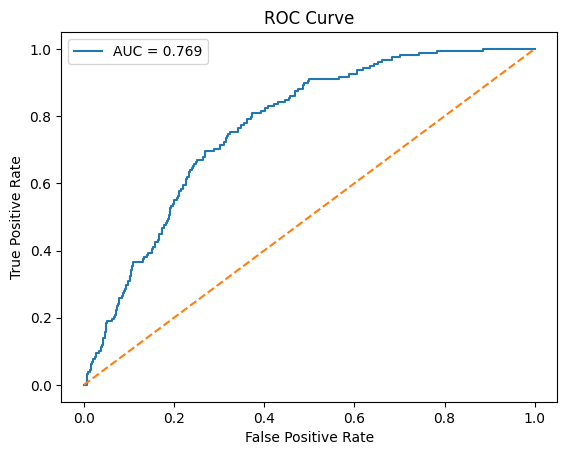

In [39]:
# Use our Logistic Regression Model to get the predicted probabilities of a hit
y_proba = model.predict_proba(X_test)[:, 1]  

# Calculate the AUC and Create the ROC Curve Plot
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

This ROC-Curve shows that our when our model predicts a hit 77% of the time it actually was a hit. That is a decent AUC score, not great but decent.

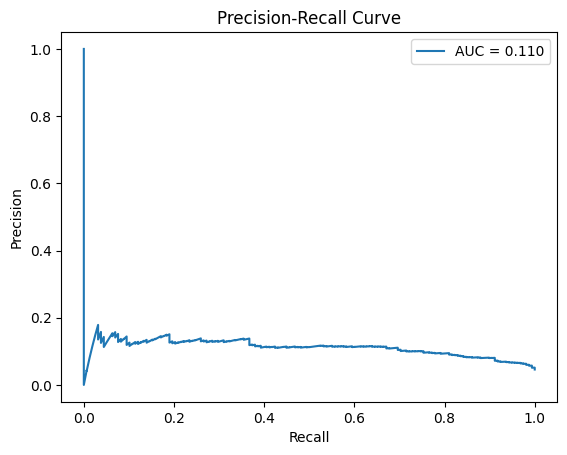

In [40]:
# Calculate the AUC and Create a Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
plt.plot(recall, precision, label=f"AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

This Precission-Recall Plot has a baseline score of the percent of the positive response, in our case that is just about 5%. So with this AUC value of 0.110 we can see that our model is better than a random guess, however it is not really a great model.

In [41]:
# Calculating the Permutation Importance for our Logistic Regression Model
perm = permutation_importance(
    model, X_test, y_test, n_repeats=10, random_state=307, scoring='roc_auc', n_jobs=-1
)

# Attaching the Feature Names to those importances
perm_df = pd.DataFrame({
    'feature': X.columns,
    'importance': perm.importances_mean,
}).sort_values('importance', ascending=False)

# Showing that Permutation Importance Table
print(perm_df)

             feature  importance
0               zone    0.239019
2        pitch_count    0.029867
5       pitch_number    0.024371
6         pitch_name    0.015921
4  release_spin_rate    0.004099
3    effective_speed    0.002864
1           p_throws    0.001692


This Permutation Importance is calculated by shuffling the feature values and then calculating the AUC score again, the amount that the AUC score drops is the importance score shown. From this we can see that zone is the most important feature.

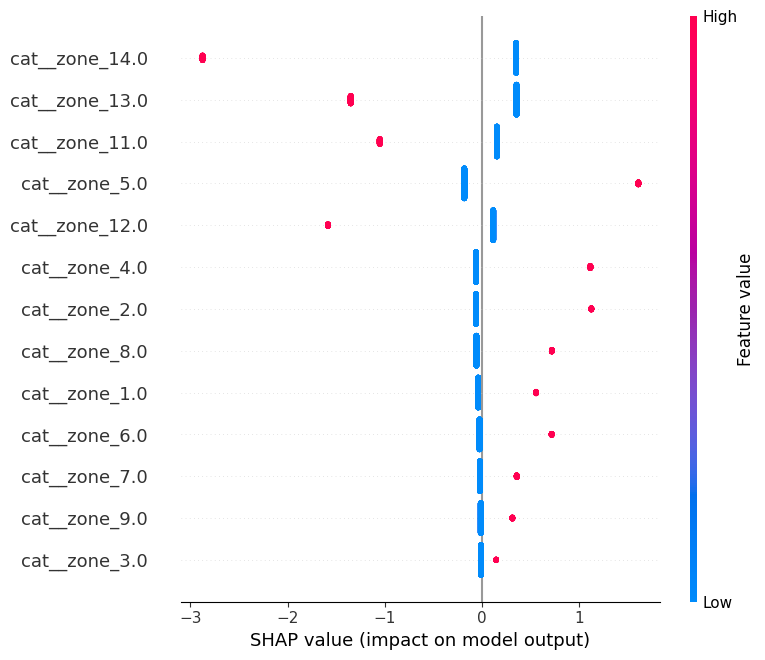

In [42]:
# Transform data using the preprosess
X_train_transformed = model.named_steps['preprocess'].transform(X_train)
X_test_transformed = model.named_steps['preprocess'].transform(X_test)

# Get Feature Names
feature_names = model.named_steps['preprocess'].get_feature_names_out()

# Pull off the Trained Model
log_reg = model.named_steps['classifier']

# Compute Shap Values
explainer = shap.LinearExplainer(log_reg, X_train_transformed)
shap_values = explainer(X_test_transformed)

# Grab only the 'Zone' Features
zone_shap = np.array([("zone" in name) for name in feature_names])
X_zone = X_test_transformed[:, zone_shap]
zone_feature_names = feature_names[zone_shap]

# Handle SHAP values depending on shape
if hasattr(shap_values, "values"):
    shap_zone = shap_values.values[:, zone_shap]
else:
    shap_zone = shap_values[:, zone_shap]
X_zone_dense = X_zone.toarray() if hasattr(X_zone, "toarray") else X_zone

# Encode original 'zone' for coloring
zone_color = X_test['zone'].astype('category').cat.codes.values

# Grab a sample from the data since we have so many points
idx = np.random.choice(len(zone_color), size=min(2000, len(zone_color)), replace=False)

# Show Plot
shap.summary_plot(
    shap_zone[idx],
    X_zone_dense[idx],
    feature_names=zone_feature_names,
    color=zone_color[idx],
    plot_type="dot"
)

These Shap values can be summarized essentially as, if the ball is thrown inside the strike zone it leads to a stronger prediction of a hit and if the ball is thrown outside the strike zone then it leads to a stronger prediction that it will not be a hit.

In [43]:
# Cluster Plot Code for our K-Means
target_map = {str(i): f"Cluster {i}" for i in range(10)}

def plot_cluster_embedding(embedding, cluster_labels, title, x_label="Component 1", y_label="Component 2"):
    cluster_ids = np.asarray(cluster_labels, dtype=int)
    unique_clusters = np.unique(cluster_ids)
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=cluster_ids,
        cmap="tab10",
        s=6,
        alpha=0.5,
    )
    handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="",
            markerfacecolor=scatter.cmap(scatter.norm(cluster_id)),
            markeredgecolor="none",
            markersize=6,
            alpha=0.8,
        )
        for cluster_id in unique_clusters
    ]
    legend_labels = [f"Cluster {cluster_id}" for cluster_id in unique_clusters]
    plt.legend(handles, legend_labels, title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.tight_layout()

In [44]:
# Creating our K-Means Model
kmeans_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('classifier', KMeans(n_clusters = 10, random_state = 307))
])

# Fit the K-Means Model
X_transformed = kmeans_model.fit_transform(X_train)
kmeans_labels = kmeans_model.named_steps['classifier'].labels_

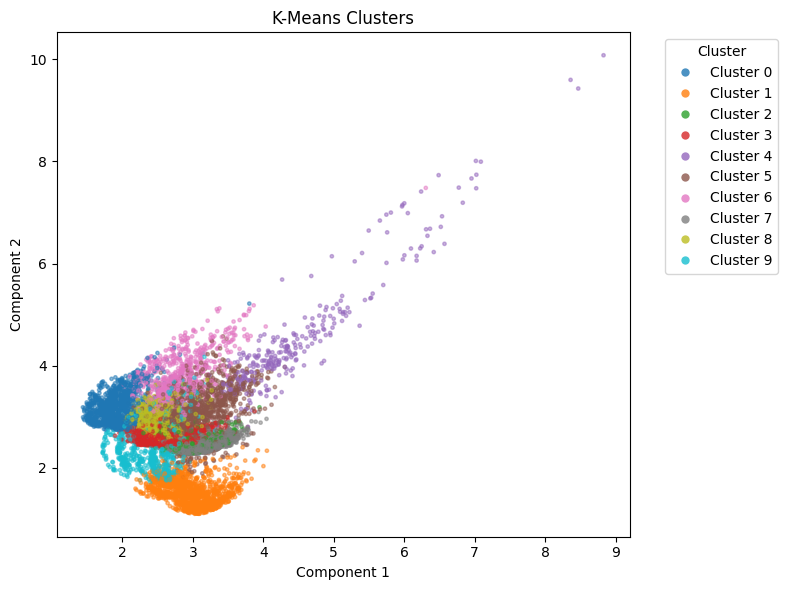

In [45]:
# Plotting that K-Means
plot_cluster_embedding(X_transformed, kmeans_labels,  title="K-Means Clusters")

This K-Means Plot shows 9 clusters, however there is not a lot of seperation. That lack of seperation indicates that the model is not finding any strong patterns that lead to a key difference. This is in-line with what we learned from supervised model, it is hard to model a hit just with pitch level data.

In [27]:
X_train_clusters = X_train.copy()
X_train_clusters['cluster'] = kmeans_labels

# Create a Summary each Cluster
summary = X_train_clusters.groupby('cluster').agg({
    'effective_speed': 'mean',
    'release_spin_rate': 'mean',
    'pitch_name': lambda x: x.value_counts().index[0],
    'zone': lambda x: x.value_counts().index[0],
    'pitch_count': lambda x: x.value_counts().index[0]
})

print(summary)

         effective_speed  release_spin_rate       pitch_name  zone pitch_count
cluster                                                                       
0              83.813770        2358.739791           Slider  13.0         0-1
1              93.520947        2235.577475  4-Seam Fastball  11.0         0-0
2              93.437793        2290.466207  4-Seam Fastball  11.0         1-0
3              93.210093        2221.070866  4-Seam Fastball  13.0         1-0
4              82.319655        1073.131034     Split-Finger  13.0         0-0
5              86.601054        1717.891037         Changeup  13.0         1-1
6              78.613416        2701.554037        Curveball  14.0         2-2
7              94.931879        2280.620493  4-Seam Fastball  11.0         1-1
8              86.809115        2441.297743           Slider  14.0         1-1
9              83.754500        2390.817500           Slider  13.0         0-0
